In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import optuna
import matplotlib.pyplot as plt

In [7]:
df= pd.read_csv('diamonds.csv')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [9]:
df = pd.get_dummies(df, drop_first=True)
X = df.drop(columns=['price']).values
y = df['price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [10]:
df

,carat,depth,table,x,y,z,price,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,326,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,3.89,3.84,2.31,326,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,327,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,334,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,335,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,3.50,2757,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,5.69,5.75,3.61,2757,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,5.66,5.68,3.56,2757,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,6.15,6.12,3.74,2757,False,False,True,...,True,False,False,False,False,True,False,False,False,False


In [11]:
X_tr = torch.FloatTensor(X_train)
y_tr = torch.FloatTensor(y_train).reshape(-1, 1)
X_te = torch.FloatTensor(X_test)
y_te = torch.FloatTensor(y_test)

In [12]:
batch_size = 256
train_dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

In [13]:
class NeuralNet2(nn.Module):
    def __init__(self, input_size=23, hidden_size=64, num_classes=1):
        super(NeuralNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [16]:
def objective(trial):

    hidden_size = trial.suggest_int(
        "hidden_size",
        16,
        128,
        step = 16
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [64, 128, 256, 512]
    )

    train_dataset = torch.utils.data.TensorDataset(
        X_tr,
        y_tr
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    model = NeuralNet2(
        input_size=X_tr.shape[1],
        hidden_size=hidden_size,
        num_classes=1
    )

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    num_epochs = 30

    for epoch in range(num_epochs):

        model.train()

        for features, labels in train_loader:

            outputs = model(features)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

    model.eval()

    with torch.no_grad():
        predictions = model(X_te)

    predictions_numpy = predictions.detach().cpu().numpy().reshape(-1, 1)
    y_test_numpy = y_te.detach().cpu().numpy().reshape(-1, 1)

    predictions_original = scaler_y.inverse_transform(predictions_numpy)
    y_test_original = scaler_y.inverse_transform(y_test_numpy)

    y_test_original = scaler_y.inverse_transform(
        y_test_numpy
    )

    rmse = np.sqrt(
        np.mean(
            (predictions_original - y_test_original) ** 2
        )
    )

    return rmse

In [17]:
study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=30
)

print("Лучший RMSE:", study.best_value)

print("\nЛучшие параметры:")

for param, value in study.best_params.items():
    print(f"{param}: {value}")

[I 2026-08-24 15:45:03,665] A new study created in memory with name: no-name-22b464c0-9504-4f64-9b90-d50eebeffd3a
[I 2026-08-24 15:45:14,313] Trial 0 finished with value: 616.63671875 and parameters: {'hidden_size': 128, 'learning_rate': 0.0005225966810115378, 'batch_size': 512}. Best is trial 0 with value: 616.63671875.
[I 2026-08-24 15:45:37,990] Trial 1 finished with value: 627.2113037109375 and parameters: {'hidden_size': 112, 'learning_rate': 0.007741085154794756, 'batch_size': 64}. Best is trial 0 with value: 616.63671875.
[I 2026-08-24 15:45:48,030] Trial 2 finished with value: 796.576904296875 and parameters: {'hidden_size': 16, 'learning_rate': 0.0002760219896451064, 'batch_size': 512}. Best is trial 0 with value: 616.63671875.
[I 2026-08-24 15:46:00,333] Trial 3 finished with value: 606.66650390625 and parameters: {'hidden_size': 80, 'learning_rate': 0.005154822138442345, 'batch_size': 256}. Best is trial 3 with value: 606.66650390625.
[I 2026-08-24 15:46:10,841] Trial 4 fini

Лучший RMSE: 562.9520874023438

Лучшие параметры:
hidden_size: 128
learning_rate: 0.0018719168615313922
batch_size: 64


In [18]:
best_params = study.best_params

model = NeuralNet2(
    input_size=X_tr.shape[1],
    hidden_size=best_params["hidden_size"],
    num_classes=1
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_params["learning_rate"]
)

train_dataset = torch.utils.data.TensorDataset(
    X_tr,
    y_tr
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True
)

In [19]:
num_epochs = 50

loss_history = []

for epoch in range(num_epochs):

    epoch_loss = 0

    model.train()

    for features, labels in train_loader:

        outputs = model(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {avg_loss:.4f}"
    )

Epoch [1/50], Loss: 0.0783
Epoch [2/50], Loss: 0.0342
Epoch [3/50], Loss: 0.0303
Epoch [4/50], Loss: 0.0278
Epoch [5/50], Loss: 0.0272
Epoch [6/50], Loss: 0.0256
Epoch [7/50], Loss: 0.0287
Epoch [8/50], Loss: 0.0257
Epoch [9/50], Loss: 0.0239
Epoch [10/50], Loss: 0.0240
Epoch [11/50], Loss: 0.0231
Epoch [12/50], Loss: 0.0234
Epoch [13/50], Loss: 0.0230
Epoch [14/50], Loss: 0.0221
Epoch [15/50], Loss: 0.0225
Epoch [16/50], Loss: 0.0248
Epoch [17/50], Loss: 0.0218
Epoch [18/50], Loss: 0.0238
Epoch [19/50], Loss: 0.0220
Epoch [20/50], Loss: 0.0214
Epoch [21/50], Loss: 0.0214
Epoch [22/50], Loss: 0.0210
Epoch [23/50], Loss: 0.0223
Epoch [24/50], Loss: 0.0211
Epoch [25/50], Loss: 0.0214
Epoch [26/50], Loss: 0.0211
Epoch [27/50], Loss: 0.0219
Epoch [28/50], Loss: 0.0207
Epoch [29/50], Loss: 0.0206
Epoch [30/50], Loss: 0.0210
Epoch [31/50], Loss: 0.0205
Epoch [32/50], Loss: 0.0205
Epoch [33/50], Loss: 0.0213
Epoch [34/50], Loss: 0.0200
Epoch [35/50], Loss: 0.0220
Epoch [36/50], Loss: 0.0203
E

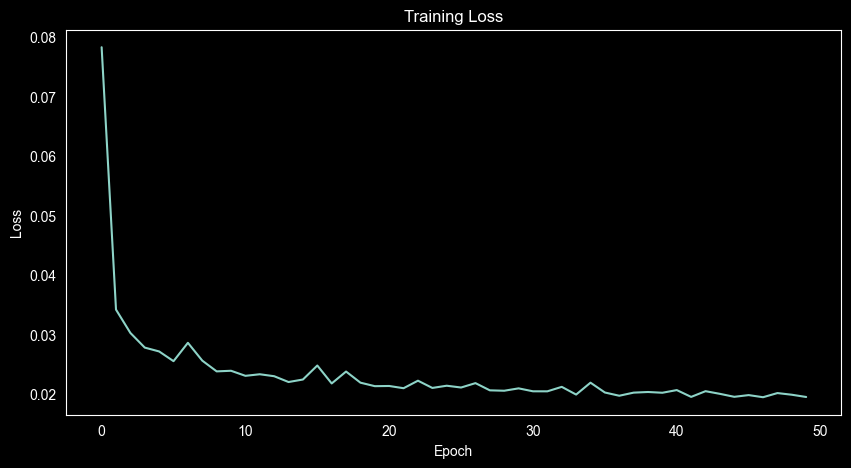

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()
plt.show()

In [23]:
model.eval()

with torch.no_grad():
   pred_scaled = model(X_te)

   pred_numpy = pred_scaled.numpy().reshape(-1, 1)
   y_test_numpy = y_te.numpy().reshape(-1, 1)

   pred_original = scaler_y.inverse_transform(pred_numpy)
   y_test_original = scaler_y.inverse_transform(y_test_numpy)

   mae = np.mean(
       np.abs(pred_original - y_test_original)
   )

   mse = np.mean(
       (pred_original - y_test_original) ** 2
   )

   rmse = np.sqrt(mse)

   r2 = 1 - (
       np.sum((y_test_original - pred_original) ** 2)
       /
       np.sum((y_test_original - np.mean(y_test_original)) ** 2)
   )

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 315.09088
MSE: 319865.16
RMSE: 565.5662
R²: 0.97987866
